In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Census.csv')

In [3]:
#Mapping all columns based on the files given to us

region_map = {
    'E12000001': 'North East', 'E12000002': 'North West', 'E12000003': 'Yorkshire and the Humber',
    'E12000004': 'East Midlands', 'E12000005': 'West Midlands', 'E12000006': 'East of England',
    'E12000007': 'London', 'E12000008': 'South East', 'E12000009': 'South West', 'W92000004': 'Wales'
}

residence_type_map = {'C': 'Resident in a communal establishment', 'H': 'Not resident in a communal establishment'}

family_composition_map = {
    1: 'Not in a family', 2: 'Married/same-sex civil partnership couple family',
    3: 'Cohabiting couple family', 4: 'Lone parent family (male head)',
    5: 'Lone parent family (female head)', 6: 'Other related family', -9: np.nan
}

population_base_map = {1: 'Usual resident', 2: 'Student living away during term-time', 3: 'Short-term resident'}

sex_map = {1: 'Male', 2: 'Female'}

age_map = {
    1: '0 to 15', 2: '16 to 24', 3: '25 to 34', 4: '35 to 44', 5: '45 to 54',
    6: '55 to 64', 7: '65 to 74', 8: '75 and over'
}

marital_status_map = {
    1: 'Single (never married or in a civil partnership)',
    2: 'Married or in a registered same-sex civil partnership',
    3: 'Separated but still legally married or in a partnership',
    4: 'Divorced or formerly in a civil partnership (now dissolved)',
    5: 'Widowed or surviving partner'
}

student_map = {1: 'Yes', 2: 'No'}

country_birth_map = {1: 'UK', 2: 'Non UK', -9: np.nan}

health_map = {
    1: 'Very good health', 2: 'Good health', 3: 'Fair health',
    4: 'Bad health', 5: 'Very bad health', -9: np.nan
}

ethnic_group_map = {
    1: 'White', 2: 'Mixed', 3: 'Asian and Asian British',
    4: 'Black or Black British', 5: 'Chinese or Other ethnic group', -9: np.nan
}

religion_map = {
    1: 'No religion', 2: 'Christian', 3: 'Buddhist', 4: 'Hindu', 5: 'Jewish', 6: 'Muslim', 7: 'Sikh',
    8: 'Other religion', 9: 'Not stated', -9: np.nan
}

economic_activity_map = {
    1: 'Economically active: Employee', 2: 'Economically active: Self-employed',
    3: 'Economically active: Unemployed', 4: 'Economically active: Full-time student',
    5: 'Economically inactive: Retired', 6: 'Economically inactive: Student',
    7: 'Economically inactive: Looking after home/family',
    8: 'Economically inactive: Long-term sick/disabled',
    9: 'Economically inactive: Other', -9: np.nan
}

occupation_map = {
    1: 'Managers, Directors and Senior Officials', 2: 'Professional Occupations',
    3: 'Associate Professional and Technical Occupations',
    4: 'Administrative and Secretarial Occupations',
    5: 'Skilled Trades Occupations',
    6: 'Caring, Leisure and Other Service Occupations',
    7: 'Sales and Customer Service Occupations',
    8: 'Process, Plant and Machine Operatives',
    9: 'Elementary Occupations', -9: np.nan
}

industry_map = {
    1: 'Agriculture, forestry and fishing',
    2: 'Mining, manufacturing, utilities, water supply',
    3: 'Construction',
    4: 'Wholesale and retail trade; repair of vehicles',
    5: 'Accommodation and food service activities',
    6: 'Transport, storage, info and communication',
    7: 'Financial and insurance activities',
    8: 'Real estate, professional, admin and support',
    9: 'Public admin and defence; social security',
    10: 'Education',
    11: 'Human health and social work',
    12: 'Other community, personal service, households',
    -9: np.nan
}

hours_worked_map = {
    1: 'Part-time: 15 or less hours',
    2: 'Part-time: 16 to 30 hours',
    3: 'Full-time: 31 to 48 hours',
    4: 'Full-time: 49 or more hours',
    -9: np.nan
}

social_grade_map = {1: 'AB', 2: 'C1', 3: 'C2', 4: 'DE', -9: np.nan}

In [4]:
columns_mapping = {
    'Region': region_map,
    'Residence Type': residence_type_map,
    'Family Composition': family_composition_map,
    'Population Base': population_base_map,
    'Sex': sex_map,
    'Age': age_map,
    'Marital Status': marital_status_map,
    'Student': student_map,
    'Country of Birth': country_birth_map,
    'Health': health_map,
    'Ethnic Group': ethnic_group_map,
    'Religion': religion_map,
    'Economic Activity': economic_activity_map,
    'Occupation': occupation_map,
    'Industry': industry_map,
    'Hours worked per week': hours_worked_map,
    'Approximated Social Grade': social_grade_map
}

In [5]:
for col, mapping in columns_mapping.items():
    if col in df.columns:
        df[col] = df[col].replace(-9, np.nan).map(mapping).astype('category')

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [8]:
print(df.head())
print(df.info())

   person_id      region                            residence_type  \
0    7394816  North East  Not resident in a communal establishment   
1    7394832  North East  Not resident in a communal establishment   
2    7394719  North East  Not resident in a communal establishment   
3    7394840  North East  Not resident in a communal establishment   
4    7394711  North East  Not resident in a communal establishment   

                                 family_composition population_base     sex  \
0  Married/same-sex civil partnership couple family  Usual resident  Female   
1                          Cohabiting couple family  Usual resident  Female   
2  Married/same-sex civil partnership couple family  Usual resident    Male   
3                                   Not in a family  Usual resident  Female   
4  Married/same-sex civil partnership couple family  Usual resident    Male   

        age                                     marital_status student  \
0  55 to 64  Married or in a r

In [9]:
print(df.describe(include=np.number))

          person_id    no_of_hours
count  5.697400e+05  267419.000000
mean   7.679353e+06      35.234789
std    1.644699e+05      13.520881
min    7.394483e+06       1.000000
25%    7.536918e+06      27.000000
50%    7.679352e+06      37.000000
75%    7.821787e+06      45.000000
max    7.964223e+06      60.000000


In [10]:
for col in df.select_dtypes(include='category').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head())
    print(f"Unique values: {df[col].nunique()}")


--- region ---
region
South East         88084
London             83582
North West         71436
East of England    59411
West Midlands      56875
Name: count, dtype: int64
Unique values: 10

--- residence_type ---
residence_type
Not resident in a communal establishment    559086
Resident in a communal establishment         10654
Name: count, dtype: int64
Unique values: 2

--- family_composition ---
family_composition
Married/same-sex civil partnership couple family    300961
Not in a family                                      96690
Cohabiting couple family                             72641
Lone parent family (female head)                     64519
Lone parent family (male head)                        9848
Name: count, dtype: int64
Unique values: 6

--- population_base ---
population_base
Usual resident                          561039
Student living away during term-time      6730
Short-term resident                       1971
Name: count, dtype: int64
Unique values: 3

--- sex ---
s

In [11]:
df.to_csv('Census_Updated.csv', index=False)


Box Plot of Age Distribution by Approximated Social Grade


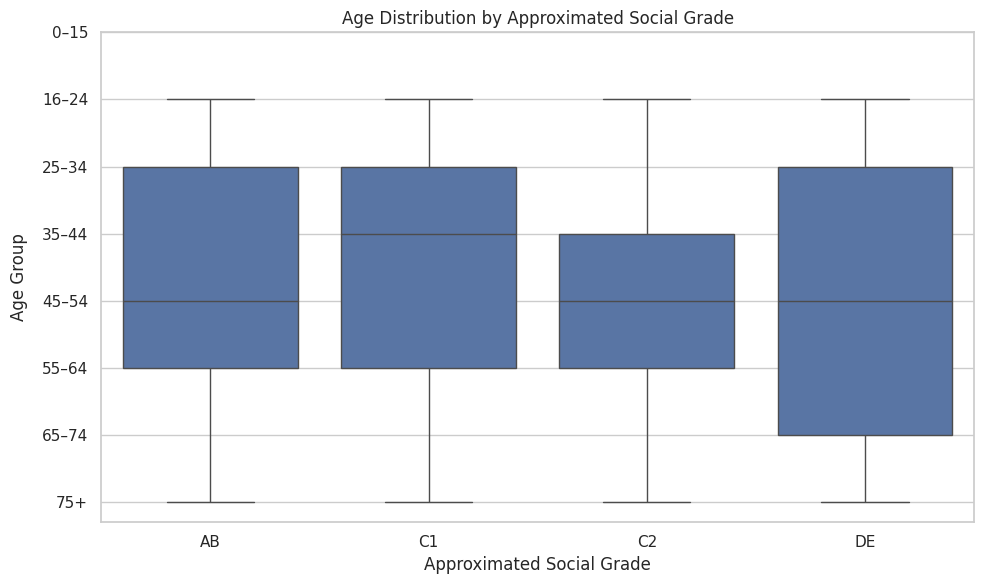

In [12]:
print("\nBox Plot of Age Distribution by Approximated Social Grade")
age_map = {           # Creating a map to allow 'age' to be converted into numerical number
    '0 to 15': 1, '16 to 24': 2, '25 to 34': 3, '35 to 44': 4,
    '45 to 54': 5, '55 to 64': 6, '65 to 74': 7, '75 and over': 8
}
df['age_numeric'] = df['age'].map(age_map)    # Fitting the map into the data

sns.set(style='whitegrid')      # Formatting

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='approximated_social_grade', y='age_numeric', data=df,)

age_labels = ['0–15', '16–24', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']    # Replacing the values of Y-Label
plt.yticks(ticks=range(1, 9), labels=age_labels)

plt.title('Age Distribution by Approximated Social Grade')
plt.xlabel('Approximated Social Grade')
plt.ylabel('Age Group', labelpad=10)
plt.tight_layout()

plt.show()


Violin Plot of No of hours by Approximated Social Grade


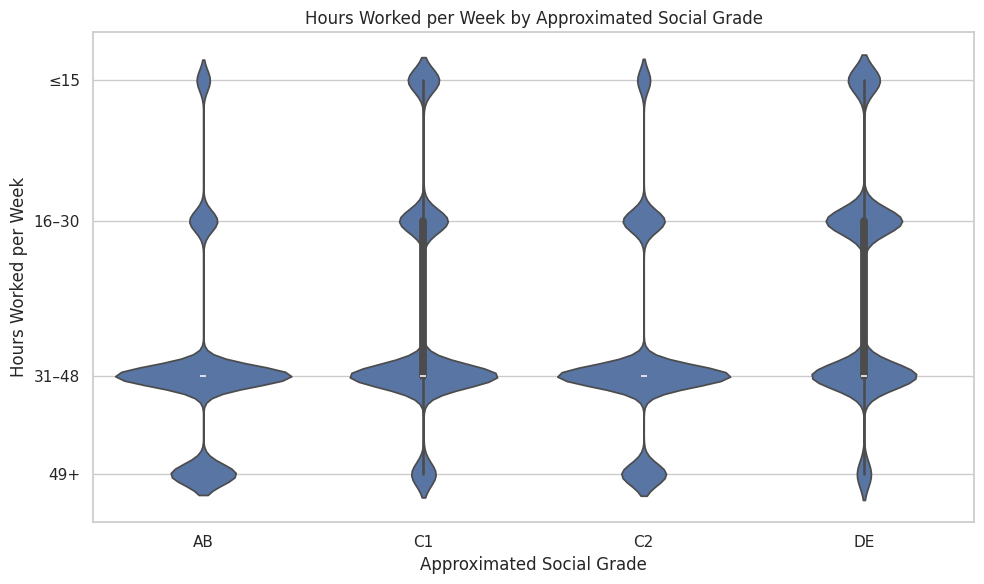

In [13]:
print("\nViolin Plot of No of hours by Approximated Social Grade")
hours_map = {                   # Creating map as well
    'Part-time: 15 or less hours': 8,
    'Part-time: 16 to 30 hours': 23,
    'Full-time: 31 to 48 hours': 39.5,
    'Full-time: 49 or more hours': 50
}
df['hours_numeric'] = df['hours_worked_per_week'].map(hours_map)        # Fitting

sns.set(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.violinplot(x='approximated_social_grade', y='hours_numeric', data=df,)

hours_labels = ['≤15', '16–30', '31–48', '49+']       # Replacing
plt.yticks([8, 23, 39.5, 50], hours_labels)

plt.title('Hours Worked per Week by Approximated Social Grade')
plt.xlabel('Approximated Social Grade')
plt.ylabel('Hours Worked per Week')
plt.tight_layout()
plt.show()


Grouped Bar Chart of Economic Activity by Sex


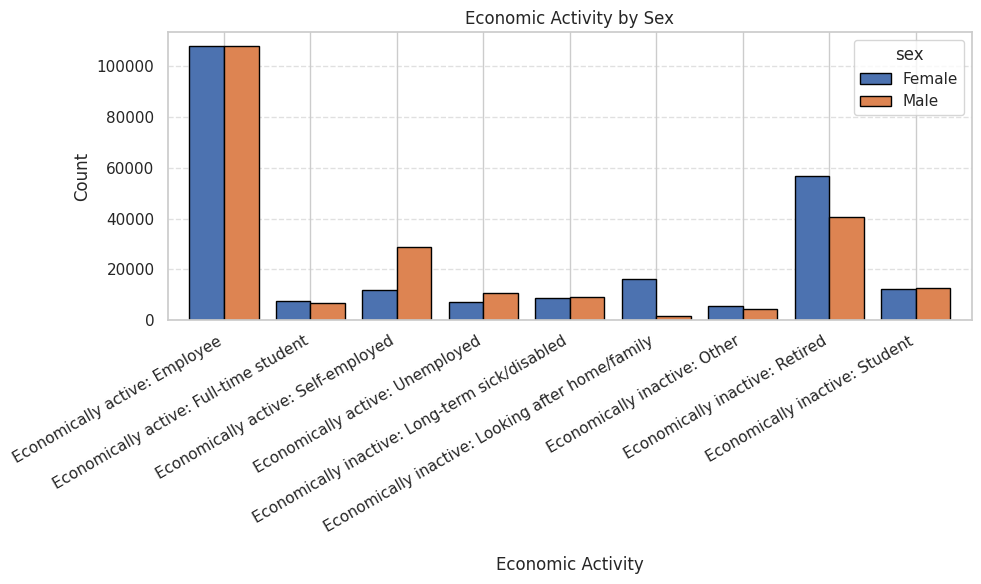

In [14]:
print("\nGrouped Bar Chart of Economic Activity by Sex")
sns.set(style='whitegrid')

df_filtered = df.dropna(subset=['economic_activity', 'sex'])      # Ensuring no NaN values

grouped = df_filtered.groupby(['economic_activity', 'sex']).size().unstack(fill_value=0)    # Groups the 2 columns together for plotting

plt.figure(figsize=(10, 6))
grouped.plot(
    kind='bar', width=0.8, edgecolor='black', ax=plt.gca())

plt.title('Economic Activity by Sex')
plt.xlabel('Economic Activity', labelpad=15)
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right', va='top')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


Heatmap of Religion vs. Ethnic Group


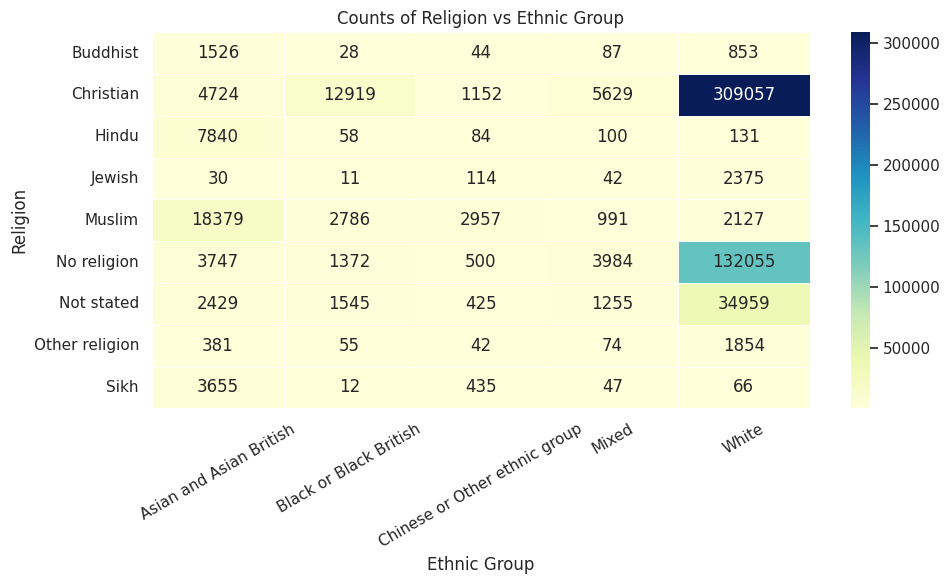

In [15]:
print("\nHeatmap of Religion vs. Ethnic Group")
sns.set(style='whitegrid')

df_filtered = df[df['religion'].notna() & df['ethnic_group'].notna()]       # Cleaning

heatmap_data = pd.crosstab(df_filtered['religion'], df_filtered['ethnic_group'])      # Fitting into crosstab to allow cross-tabulation between 2 columns (Counts Frequency)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, linecolor='white')

plt.title('Counts of Religion vs Ethnic Group')
plt.xlabel('Ethnic Group')
plt.ylabel('Religion')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Stacked Bar Chart of Approximated Social Grade by Economic Activity


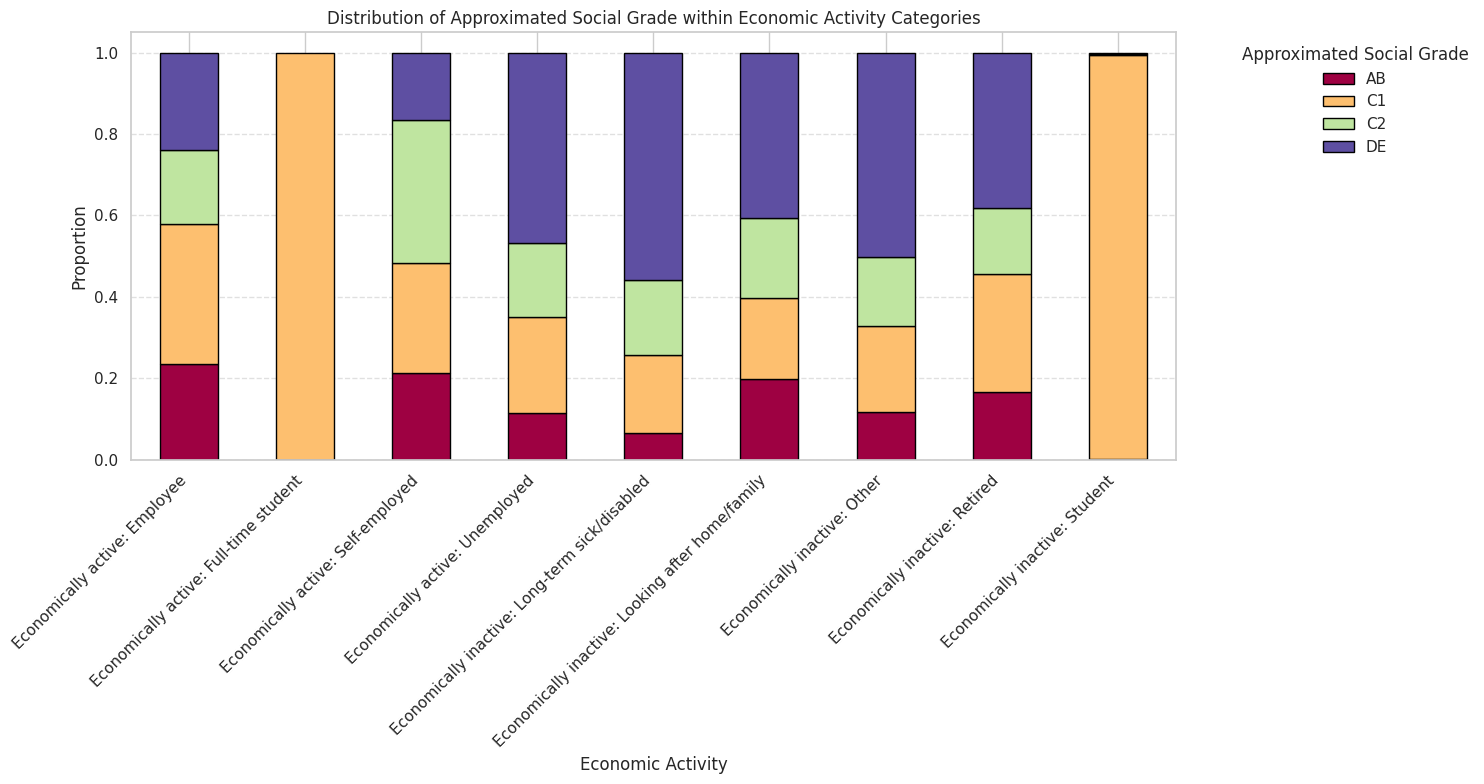

In [16]:
print("\nStacked Bar Chart of Approximated Social Grade by Economic Activity")

# Drops the NaN values
df_filtered_stacked = df[(df['approximated_social_grade'].notna()) & (df['economic_activity'].notna())].copy()

social_grade_order = ['AB', 'C1', 'C2', 'DE'] # Order
# Creates crosstab with proportions with a sum to 1
social_grade_economic_activity = pd.crosstab(df_filtered_stacked['economic_activity'], df_filtered_stacked['approximated_social_grade'], normalize='index')
# Ensure alignment according to order given
social_grade_economic_activity = social_grade_economic_activity[social_grade_economic_activity.columns.intersection(social_grade_order)]

plt.figure(figsize=(15, 8))
social_grade_economic_activity.plot(kind='bar', stacked=True, cmap='Spectral', edgecolor='black', ax=plt.gca())

plt.title('Distribution of Approximated Social Grade within Economic Activity Categories')
plt.xlabel('Economic Activity')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Approximated Social Grade', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()